# Calculating \\(\pi \\) using a Monte Carlo algorithm

- Gustavo Aguilar

In [3]:
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.patches as patches

Text(0.5, 1.0, 'Area for points')

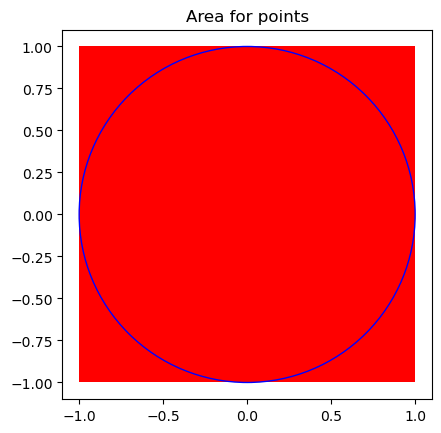

In [5]:
#Generating a figure

fig = plt.figure()
ax = fig.add_subplot(111, aspect='equal')

#Rectangle
rectangle = patches.Rectangle((-1,-1),2,2, facecolor='red')
ax.add_patch(rectangle)

#Circle
circle = patches.Circle((0,0),1, facecolor='none', edgecolor='blue')
ax.add_patch(circle)

plt.xlim([-1.1,1.1])
plt.ylim([-1.1,1.1])
plt.title('Area for points')

## Comparing the areas

Area of the circle: \\( A_\mathrm{circle} = \pi r^2 = \pi\\)

Area of the square: \\( A_\mathrm{square} = a^2 = 4 \\)

This means \\( \pi = 4\frac{A_\mathrm{circle}}{A_\mathrm{square}}\\). We can use this ratio to estimate the value of \\( \pi \\). 

### Measure the area ratio by counting randomly generated points

In [9]:
# Number of points
points = 1000

#Genrates numbers between -1 and 1
rand = 2*np.random.rand(2*points) - 1

In [11]:
#This command reshapes our points as a pair of lists
randpoints = rand.reshape( points,2)

In [13]:
#Norm of the points to help if point is in or out of the circle
normpoints = randpoints[:,0]**2 + randpoints[:,1]**2

In [15]:
#Condition that determines if the point in or out of the circle

pointsOut = randpoints[normpoints > 1] #condition can be commented out since we only want to know what points are inside the circle
pointsIn = randpoints[normpoints <= 1]

In [17]:
#Using the formula, we can get an aproximation for pi
piapprox = 4 * len(pointsIn) / points

print(piapprox)

3.204


In [19]:
#Comparing to the actual value of pi

piapprox - np.pi #This is a good result, accuracy will increase with more points

0.062407346410207065

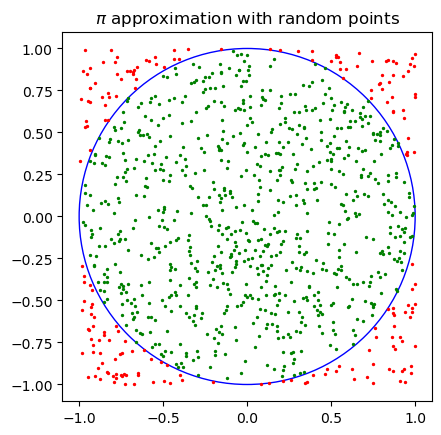

In [21]:
#Generating a figure to show the points inside the circle

fig = plt.figure()
ax = fig.add_subplot(111, aspect='equal')

#Rectangle
# rectangle = patches.Rectangle((-1,-1),2,2, facecolor='red')
# ax.add_patch(rectangle)

#Circle
circle = patches.Circle((0,0),1, facecolor='none', edgecolor='blue')
ax.add_patch(circle)

plt.xlim([-1.1,1.1])
plt.ylim([-1.1,1.1])
plt.title('$\pi$ approximation with random points')

plt.scatter(pointsIn[:,0], pointsIn[:,1], color= 'green', s =2)
plt.scatter(pointsOut[:,0], pointsOut[:,1], color= 'red', s =2)

### Alternative: Loop method

In [24]:
#Easier to code, but is much slower

i = 0
counter = 0

while i<points:
    if np.linalg.norm(np.random.rand(2) -1) < 1:
        counter = counter + 1
    i = i+1

In [28]:
piapprox = 4* counter / points
print(piapprox)

3.144


In [30]:
#Comparing to the actual value of pi

piapprox - np.pi

0.002407346410207012

### Time comparison

Array/List method

In [37]:
%%timeit

rand = 2*np.random.rand(2*points) - 1
randpoints = rand.reshape( points,2)
normpoints = randpoints[:,0]**2 + randpoints[:,1]**2
pointsIn = randpoints[normpoints <= 1]
piapprox = 4 * len(pointsIn) / points

21 µs ± 235 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


Loop method

In [41]:
%%timeit

i = 0
counter = 0

while i<points:
    if np.linalg.norm(np.random.rand(2) -1) < 1:
        counter = counter + 1
    i = i+1

2.02 ms ± 16 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
